In [4]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sentence_transformers import SentenceTransformer
from datasets import load_dataset

# Make sure Python finds your src/ folder
sys.path.insert(0, r"e:\TalentLens")
from src.data.preprocess import clean_text

sns.set_theme(style="whitegrid")
print("All imports OK")


All imports OK


In [5]:
# Load from cache — won't re-download since files already exist
dataset = load_dataset(
    "cnamuangtoun/resume-job-description-fit",
    cache_dir=r"e:\TalentLens\notebooks\hf_cache"
)

train_df = dataset['train'].to_pandas()
test_df  = dataset['test'].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (6241, 3)
Test shape:  (1759, 3)


In [6]:
# Reuse the same clean_text function from Week 1
# This ensures baseline sees identical text to what the transformer will see in Week 3
train_df['resume_clean'] = train_df['resume_text'].apply(clean_text)
train_df['jd_clean']     = train_df['job_description_text'].apply(clean_text)

test_df['resume_clean']  = test_df['resume_text'].apply(clean_text)
test_df['jd_clean']      = test_df['job_description_text'].apply(clean_text)

print("Cleaning done")
print(train_df[['resume_clean', 'jd_clean']].head(2))

Cleaning done
                                        resume_clean  \
0  summaryhighly motivated sales associate with e...   
1  professional summarycurrently working with cat...   

                                            jd_clean  
0  net2source inc. is an award-winning total work...  
1  at salas obrien we tell our clients that were ...  


In [7]:
# Load the mappings saved in Week 1 — don't redefine them manually
with open(r"e:\TalentLens\data\processed\label2id.json") as f:
    label2id = json.load(f)

with open(r"e:\TalentLens\data\processed\id2label.json") as f:
    id2label = json.load(f)

print("label2id:", label2id)
print("id2label:", id2label)

# Add integer label column to both splits
train_df['label_id'] = train_df['label'].map(label2id)
test_df['label_id']  = test_df['label'].map(label2id)

print("\nNull check — train:", train_df['label_id'].isnull().sum())
print("Null check — test: ", test_df['label_id'].isnull().sum())

label2id: {'No Fit': 0, 'Potential Fit': 1, 'Good Fit': 2}
id2label: {'0': 'No Fit', '1': 'Potential Fit', '2': 'Good Fit'}

Null check — train: 0
Null check — test:  0


In [8]:
# Combine resume and JD text for fitting the vectorizer
# We fit on train only — never on test (that would be leakage)
# max_features limits vocabulary size — keeps it manageable
# ngram_range=(1,2) means single words AND two-word phrases are features

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit on train, transform both train and test
train_resume_tfidf = tfidf.fit_transform(train_df['resume_clean'])
train_jd_tfidf     = tfidf.transform(train_df['jd_clean'])

test_resume_tfidf  = tfidf.transform(test_df['resume_clean'])
test_jd_tfidf      = tfidf.transform(test_df['jd_clean'])

print("Train TF-IDF shape:", train_resume_tfidf.shape)
print("Test  TF-IDF shape:", test_resume_tfidf.shape)

Train TF-IDF shape: (6241, 10000)
Test  TF-IDF shape: (1759, 10000)


In [9]:
# Compute row-wise cosine similarity between resume and JD vectors
# Result is a (n_samples, 1) array — one score per resume-JD pair

train_sim_scores = cosine_similarity(
    train_resume_tfidf, train_jd_tfidf
).diagonal().reshape(-1, 1)

test_sim_scores = cosine_similarity(
    test_resume_tfidf, test_jd_tfidf
).diagonal().reshape(-1, 1)

print("Train similarity scores — min/max/mean:")
print(f"  min:  {train_sim_scores.min():.4f}")
print(f"  max:  {train_sim_scores.max():.4f}")
print(f"  mean: {train_sim_scores.mean():.4f}")

Train similarity scores — min/max/mean:
  min:  0.0026
  max:  0.5119
  mean: 0.1772


In [10]:
# Convert continuous similarity score into 3 classes using thresholds
# These are starting values — you can tune them after seeing results

def score_to_class(scores, low_threshold=0.15, high_threshold=0.35):
    """
    scores         : numpy array of shape (n,) or (n,1)
    low_threshold  : below this → No Fit (0)
    high_threshold : above this → Good Fit (2)
    between        : Potential Fit (1)
    """
    scores = scores.flatten()
    predictions = np.zeros(len(scores), dtype=int)
    predictions[scores >= low_threshold] = 1
    predictions[scores >= high_threshold] = 2
    return predictions

train_preds = score_to_class(train_sim_scores)
test_preds  = score_to_class(test_sim_scores)

# Quick sanity check — what classes are being predicted?
unique, counts = np.unique(test_preds, return_counts=True)
print("Predicted class distribution on test:")
for cls, cnt in zip(unique, counts):
    print(f"  {id2label[str(cls)]}: {cnt}")

Predicted class distribution on test:
  No Fit: 615
  Potential Fit: 1118
  Good Fit: 26


In [11]:
y_test = test_df['label_id'].values

print("=== Baseline 1: TF-IDF + Cosine Similarity ===\n")
print(f"Accuracy: {accuracy_score(y_test, test_preds):.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test,
    test_preds,
    target_names=['No Fit', 'Potential Fit', 'Good Fit']
))

=== Baseline 1: TF-IDF + Cosine Similarity ===

Accuracy: 0.3508

Classification Report:
               precision    recall  f1-score   support

       No Fit       0.55      0.39      0.46       857
Potential Fit       0.25      0.62      0.35       444
     Good Fit       0.12      0.01      0.01       458

     accuracy                           0.35      1759
    macro avg       0.30      0.34      0.28      1759
 weighted avg       0.36      0.35      0.32      1759



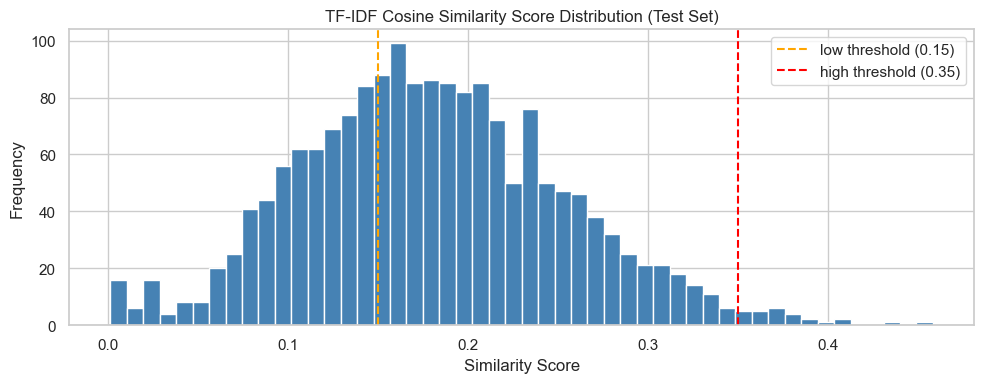

Scores above 0.35 (predicted Good Fit): 26
Scores above 0.15 (predicted Potential Fit or above): 1144


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(test_sim_scores.flatten(), bins=50, color='steelblue', edgecolor='white')
plt.title("TF-IDF Cosine Similarity Score Distribution (Test Set)")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.axvline(x=0.15, color='orange', linestyle='--', label='low threshold (0.15)')
plt.axvline(x=0.35, color='red', linestyle='--', label='high threshold (0.35)')
plt.legend()
plt.tight_layout()
plt.savefig(r"e:\TalentLens\reports\figures\baseline1_score_distribution.png", dpi=150)
plt.show()

print(f"Scores above 0.35 (predicted Good Fit): {(test_sim_scores.flatten() > 0.35).sum()}")
print(f"Scores above 0.15 (predicted Potential Fit or above): {(test_sim_scores.flatten() > 0.15).sum()}")

Baseline 2

In [13]:
# Load a pretrained sentence transformer
# all-MiniLM-L6-v2 is fast, lightweight, and strong — good fit for free tier
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding train resumes...")
train_resume_emb = model.encode(
    train_df['resume_clean'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("Encoding train JDs...")
train_jd_emb = model.encode(
    train_df['jd_clean'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("Encoding test resumes...")
test_resume_emb = model.encode(
    test_df['resume_clean'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("Encoding test JDs...")
test_jd_emb = model.encode(
    test_df['jd_clean'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("\nEmbedding shapes:")
print("Train resume:", train_resume_emb.shape)
print("Train JD:    ", train_jd_emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train resumes...


Batches:   0%|          | 0/98 [00:00<?, ?it/s]

Encoding train JDs...


...

Encoding test resumes...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Encoding test JDs...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]


Embedding shapes:
Train resume: (6241, 384)
Train JD:     (6241, 384)


In [14]:
# Three ways to combine two embeddings — we use all three concatenated
# 1. Concatenation      : [resume | jd] — preserves all information
# 2. Difference         : |resume - jd| — captures how different they are
# 3. Element-wise product: resume * jd  — captures similarity per dimension

def combine_embeddings(resume_emb, jd_emb):
    concat  = np.concatenate([resume_emb, jd_emb], axis=1)
    diff    = np.abs(resume_emb - jd_emb)
    product = resume_emb * jd_emb
    return np.concatenate([concat, diff, product], axis=1)

X_train = combine_embeddings(train_resume_emb, train_jd_emb)
X_test  = combine_embeddings(test_resume_emb, test_jd_emb)

y_train = train_df['label_id'].values
y_test  = test_df['label_id'].values

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (6241, 1536)
X_test shape:  (1759, 1536)


In [15]:
# class_weight='balanced' handles the 50/25/25 imbalance automatically
# max_iter=1000 ensures it converges — logistic regression on high-dim data
# can need more iterations than the default 100

clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

clf.fit(X_train, y_train)
print("Training done")

Training done


In [16]:
test_preds_b2 = clf.predict(X_test)

print("=== Baseline 2: Sentence Embeddings + Logistic Regression ===\n")
print(f"Accuracy: {accuracy_score(y_test, test_preds_b2):.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test,
    test_preds_b2,
    target_names=['No Fit', 'Potential Fit', 'Good Fit']
))

=== Baseline 2: Sentence Embeddings + Logistic Regression ===

Accuracy: 0.4991

Classification Report:
               precision    recall  f1-score   support

       No Fit       0.67      0.56      0.61       857
Potential Fit       0.35      0.48      0.41       444
     Good Fit       0.42      0.41      0.41       458

     accuracy                           0.50      1759
    macro avg       0.48      0.48      0.48      1759
 weighted avg       0.53      0.50      0.51      1759



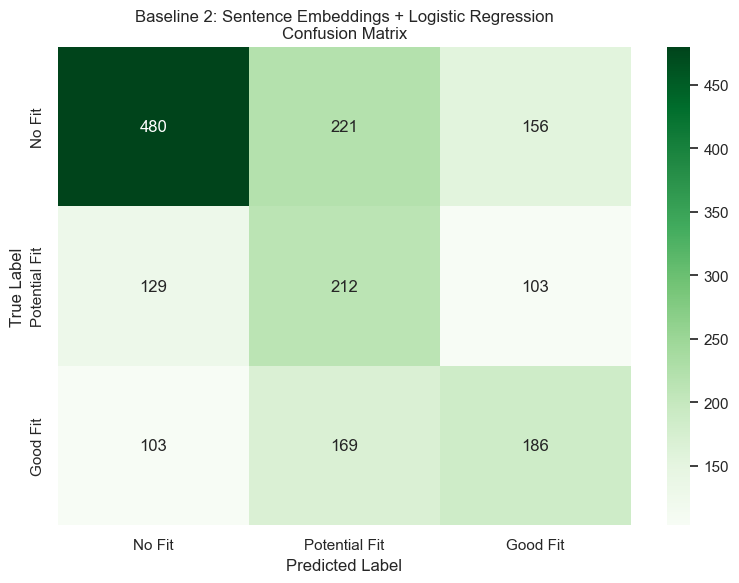

In [17]:
cm2 = confusion_matrix(y_test, test_preds_b2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Fit', 'Potential Fit', 'Good Fit'],
    yticklabels=['No Fit', 'Potential Fit', 'Good Fit']
)
plt.title("Baseline 2: Sentence Embeddings + Logistic Regression\nConfusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(r"e:\TalentLens\reports\figures\baseline2_confusion_matrix.png", dpi=150)
plt.show()

In [18]:
print("=" * 50)
print("BASELINE COMPARISON SUMMARY")
print("=" * 50)
print(f"Majority class baseline (always predict No Fit) : ~0.50 accuracy, ~0.22 macro F1")
print(f"Baseline 1 — TF-IDF + Cosine Similarity         : 0.35 accuracy, 0.28 macro F1")
print(f"Baseline 2 — Sentence Emb + Logistic Regression : {accuracy_score(y_test, test_preds_b2):.2f} accuracy, ??? macro F1")
print("=" * 50)
print("Target for Week 3 fine-tuned bi-encoder: beat Baseline 2 macro F1")

BASELINE COMPARISON SUMMARY
Majority class baseline (always predict No Fit) : ~0.50 accuracy, ~0.22 macro F1
Baseline 1 — TF-IDF + Cosine Similarity         : 0.35 accuracy, 0.28 macro F1
Baseline 2 — Sentence Emb + Logistic Regression : 0.50 accuracy, ??? macro F1
Target for Week 3 fine-tuned bi-encoder: beat Baseline 2 macro F1


In [19]:
np.save(r"e:\TalentLens\data\processed\train_resume_emb.npy", train_resume_emb)
np.save(r"e:\TalentLens\data\processed\train_jd_emb.npy", train_jd_emb)
np.save(r"e:\TalentLens\data\processed\test_resume_emb.npy", test_resume_emb)
np.save(r"e:\TalentLens\data\processed\test_jd_emb.npy", test_jd_emb)
print("Embeddings saved")

Embeddings saved
